# Task 2: End-to-End ML Pipeline with Scikit-learn Pipeline API

**Objective:** Build a reusable and production-ready ML pipeline for predicting customer churn.

**Dataset:** Telco Customer Churn Dataset (Kaggle)

**Models:** Logistic Regression and Random Forest with GridSearchCV

**Skills:** ML pipeline construction, hyperparameter tuning, model export with joblib

## 1. Install Dependencies

In [1]:
!pip install scikit-learn pandas matplotlib seaborn joblib -q
print('Dependencies ready.')

Dependencies ready.


## 2. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

plt.rcParams['figure.figsize'] = (8, 5)
print('Libraries loaded.')

Libraries loaded.


## 3. Load the Dataset

> **Dataset:** Download the Telco Customer Churn dataset from Kaggle:
> https://www.kaggle.com/datasets/blastchar/telco-customer-churn
> Upload `WA_Fn-UseC_-Telco-Customer-Churn.csv` to your Colab session.

In [19]:
# Load dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 4. Exploratory Data Analysis

In [4]:
print('Dataset Info:')
df.info()
print('\nMissing values:')
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

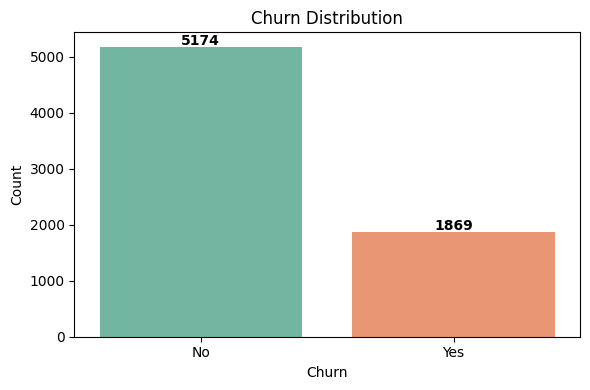

Churn rate: 26.5%


In [5]:
# Churn distribution
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(x=churn_counts.index, y=churn_counts.values, palette='Set2')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
for i, v in enumerate(churn_counts.values):
    plt.text(i, v + 30, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150)
plt.show()

print(f'Churn rate: {churn_counts["Yes"] / len(df) * 100:.1f}%')

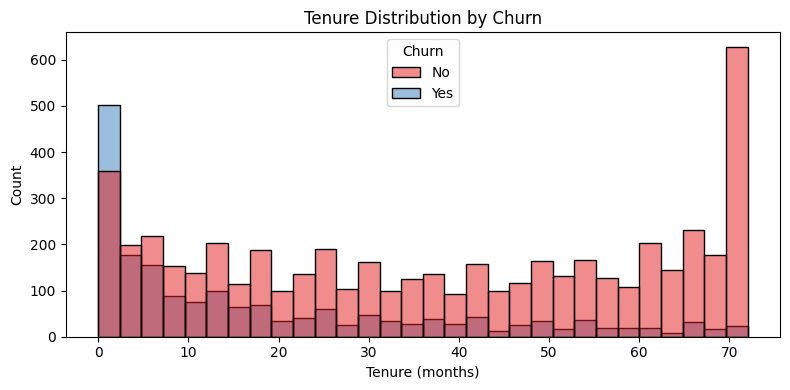

In [6]:
# Tenure vs Churn
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, palette='Set1')
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (months)')
plt.tight_layout()
plt.savefig('tenure_churn.png', dpi=150)
plt.show()

## 5. Data Preprocessing

In [7]:
# Drop customerID (not a feature)
df.drop('customerID', axis=1, inplace=True)

# Fix TotalCharges – convert to numeric (has spaces)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Encode target variable
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print('Preprocessing done.')
print(f'Shape after cleaning: {df.shape}')

Preprocessing done.
Shape after cleaning: (7043, 20)


In [8]:
# Identify numerical and categorical columns
TARGET = 'Churn'
NUMERICAL_COLS   = ['tenure', 'MonthlyCharges', 'TotalCharges']
CATEGORICAL_COLS = [c for c in df.columns if c not in NUMERICAL_COLS + [TARGET]]

print(f'Numerical features  : {NUMERICAL_COLS}')
print(f'Categorical features: {CATEGORICAL_COLS}')

X = df.drop(TARGET, axis=1)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTraining samples : {len(X_train)}')
print(f'Testing samples  : {len(X_test)}')

Numerical features  : ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Training samples : 5634
Testing samples  : 1409


## 6. Build the Pipeline

In [9]:
# Preprocessing: scale numerical, one-hot encode categorical
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUMERICAL_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL_COLS)
])

# Pipeline 1 – Logistic Regression
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(max_iter=1000, random_state=42))
])

# Pipeline 2 – Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(random_state=42, n_jobs=-1))
])

print('Pipelines created.')

Pipelines created.


## 7. Train and Evaluate Both Models

In [10]:
def evaluate_pipeline(name, pipeline, X_train, X_test, y_train, y_test):
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)
    proba = pipeline.predict_proba(X_test)[:, 1]

    acc    = accuracy_score(y_test, preds)
    f1     = f1_score(y_test, preds)
    roc    = roc_auc_score(y_test, proba)

    print(f'--- {name} ---')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  F1 Score : {f1:.4f}')
    print(f'  ROC-AUC  : {roc:.4f}\n')
    return pipeline, preds, proba

lr_pipeline, lr_preds, lr_proba = evaluate_pipeline(
    'Logistic Regression', lr_pipeline, X_train, X_test, y_train, y_test)

rf_pipeline, rf_preds, rf_proba = evaluate_pipeline(
    'Random Forest', rf_pipeline, X_train, X_test, y_train, y_test)

--- Logistic Regression ---
  Accuracy : 0.8055
  F1 Score : 0.6040
  ROC-AUC  : 0.8419

--- Random Forest ---
  Accuracy : 0.7821
  F1 Score : 0.5370
  ROC-AUC  : 0.8179



## 8. Hyperparameter Tuning with GridSearchCV

In [11]:
# Tune Random Forest (best performing model)
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth':    [5, 10, None],
    'classifier__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print('Running GridSearchCV...')
grid_search.fit(X_train, y_train)

print(f'\nBest parameters : {grid_search.best_params_}')
print(f'Best CV F1 Score: {grid_search.best_score_:.4f}')

Running GridSearchCV...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters : {'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Best CV F1 Score: 0.5833


In [12]:
# Evaluate best model on test set
best_model = grid_search.best_estimator_
best_preds = best_model.predict(X_test)
best_proba = best_model.predict_proba(X_test)[:, 1]

print('Best Model (Tuned Random Forest) – Test Set Results:')
print(f'  Accuracy : {accuracy_score(y_test, best_preds):.4f}')
print(f'  F1 Score : {f1_score(y_test, best_preds):.4f}')
print(f'  ROC-AUC  : {roc_auc_score(y_test, best_proba):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, best_preds, target_names=['No Churn', 'Churn']))

Best Model (Tuned Random Forest) – Test Set Results:
  Accuracy : 0.8062
  F1 Score : 0.5857
  ROC-AUC  : 0.8400

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.68      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409



## 9. Visualisations

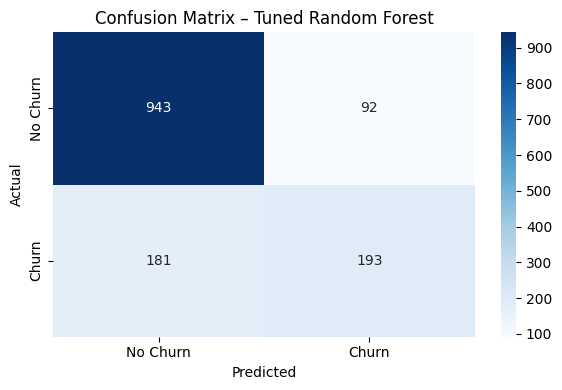

In [13]:
# Confusion matrix
cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix – Tuned Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('churn_confusion_matrix.png', dpi=150)
plt.show()

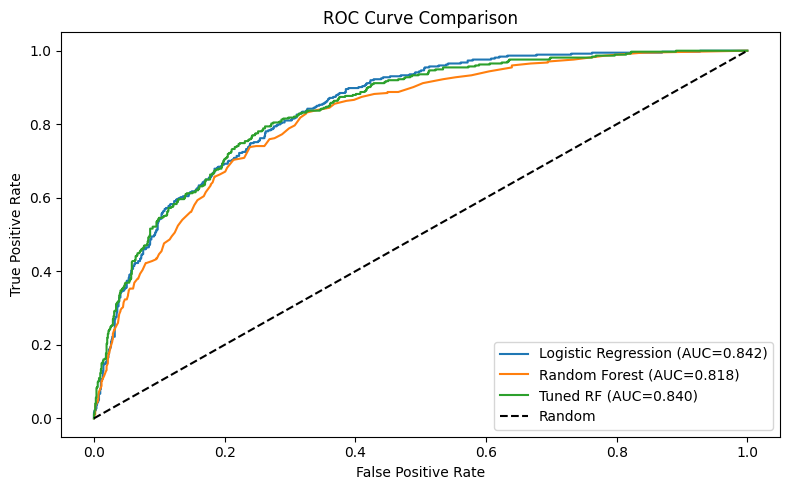

In [14]:
# ROC Curve comparison
plt.figure(figsize=(8, 5))
for name, proba in [('Logistic Regression', lr_proba),
                     ('Random Forest', rf_proba),
                     ('Tuned RF', best_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

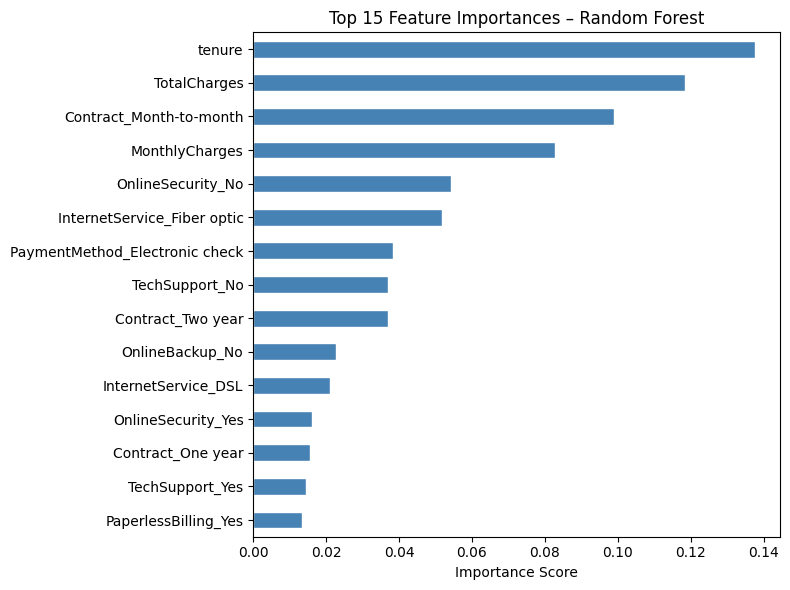

In [15]:
# Feature importance from best RF model
rf_clf = best_model.named_steps['classifier']
ohe_features = best_model.named_steps['preprocessor']\
    .named_transformers_['cat'].get_feature_names_out(CATEGORICAL_COLS).tolist()
all_features = NUMERICAL_COLS + ohe_features

importances = pd.Series(rf_clf.feature_importances_, index=all_features)
top15 = importances.nlargest(15).sort_values()

plt.figure(figsize=(8, 6))
top15.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 15 Feature Importances – Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

## 10. Export the Pipeline with joblib

In [16]:
SAVE_PATH = 'churn_pipeline.pkl'
joblib.dump(best_model, SAVE_PATH)
print(f'Pipeline exported to: {SAVE_PATH}')

# Verify by loading and predicting
loaded_pipeline = joblib.load(SAVE_PATH)
sample = X_test.iloc[:3]
sample_preds = loaded_pipeline.predict(sample)
print(f'Sample predictions from loaded pipeline: {sample_preds}')
print('Pipeline export verified successfully.')

Pipeline exported to: churn_pipeline.pkl
Sample predictions from loaded pipeline: [0 1 0]
Pipeline export verified successfully.
